In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from xgboost import XGBRegressor
from pytrends.request import TrendReq
import requests
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print("All imports successful")

All imports successful


In [4]:
cities = [
    {"city": "Austin",       "country": "USA",          "lat": 30.27,  "lon": -97.74},
    {"city": "New York",     "country": "USA",          "lat": 40.71,  "lon": -74.01},
    {"city": "Chicago",      "country": "USA",          "lat": 41.88,  "lon": -87.63},
    {"city": "Seattle",      "country": "USA",          "lat": 47.61,  "lon": -122.33},
    {"city": "Kansas City",  "country": "USA",          "lat": 39.10,  "lon": -94.58},
    {"city": "Paris",        "country": "France",       "lat": 48.85,  "lon": 2.35},
    {"city": "Dublin",       "country": "Ireland",      "lat": 53.33,  "lon": -6.25},
    {"city": "Lisbon",       "country": "Portugal",     "lat": 38.72,  "lon": -9.14},
    {"city": "Budapest",     "country": "Hungary",      "lat": 47.50,  "lon": 19.04},
    {"city": "Ljubljana",    "country": "Slovenia",     "lat": 46.05,  "lon": 14.51},
    {"city": "Reykjavik",    "country": "Iceland",      "lat": 64.13,  "lon": -21.82},
    {"city": "Mostar",       "country": "Bosnia",       "lat": 43.34,  "lon": 17.81},
    {"city": "Tel Aviv",     "country": "Israel",       "lat": 32.08,  "lon": 34.78},
    {"city": "Jerusalem",    "country": "Israel",       "lat": 31.77,  "lon": 35.22},
    {"city": "Baku",         "country": "Azerbaijan",   "lat": 40.41,  "lon": 49.87},
    {"city": "Bangkok",      "country": "Thailand",     "lat": 13.76,  "lon": 100.50},
    {"city": "Singapore",    "country": "Singapore",    "lat": 1.35,   "lon": 103.82},
    {"city": "Chiang Mai",   "country": "Thailand",     "lat": 18.79,  "lon": 98.98},
    {"city": "Bishkek",      "country": "Kyrgyzstan",   "lat": 42.87,  "lon": 74.59},
    {"city": "Marrakech",    "country": "Morocco",      "lat": 31.63,  "lon": -7.99},
    {"city": "Cape Town",    "country": "South Africa", "lat": -33.93, "lon": 18.42},
    {"city": "Medellin",     "country": "Colombia",     "lat": 6.25,   "lon": -75.56},
    {"city": "Tbilisi",      "country": "Georgia",      "lat": 41.69,  "lon": 44.83},
]

df_cities = pd.DataFrame(cities)
print(f"{len(df_cities)} cities loaded")
df_cities

23 cities loaded


,city,country,lat,lon
0,Austin,USA,30.27,-97.74
1,New York,USA,40.71,-74.01
2,Chicago,USA,41.88,-87.63
3,Seattle,USA,47.61,-122.33
4,Kansas City,USA,39.10,-94.58
5,Paris,France,48.85,2.35
6,Dublin,Ireland,53.33,-6.25
7,Lisbon,Portugal,38.72,-9.14
8,Budapest,Hungary,47.50,19.04
9,Ljubljana,Slovenia,46.05,14.51


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from xgboost import XGBRegressor
import requests
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── City list ──────────────────────────────────────────
cities = [
    {"city": "Austin",       "country": "USA",          "lat": 30.27,  "lon": -97.74},
    {"city": "New York",     "country": "USA",          "lat": 40.71,  "lon": -74.01},
    {"city": "Chicago",      "country": "USA",          "lat": 41.88,  "lon": -87.63},
    {"city": "Seattle",      "country": "USA",          "lat": 47.61,  "lon": -122.33},
    {"city": "Kansas City",  "country": "USA",          "lat": 39.10,  "lon": -94.58},
    {"city": "Paris",        "country": "France",       "lat": 48.85,  "lon": 2.35},
    {"city": "Dublin",       "country": "Ireland",      "lat": 53.33,  "lon": -6.25},
    {"city": "Lisbon",       "country": "Portugal",     "lat": 38.72,  "lon": -9.14},
    {"city": "Budapest",     "country": "Hungary",      "lat": 47.50,  "lon": 19.04},
    {"city": "Ljubljana",    "country": "Slovenia",     "lat": 46.05,  "lon": 14.51},
    {"city": "Reykjavik",    "country": "Iceland",      "lat": 64.13,  "lon": -21.82},
    {"city": "Mostar",       "country": "Bosnia",       "lat": 43.34,  "lon": 17.81},
    {"city": "Tel Aviv",     "country": "Israel",       "lat": 32.08,  "lon": 34.78},
    {"city": "Jerusalem",    "country": "Israel",       "lat": 31.77,  "lon": 35.22},
    {"city": "Baku",         "country": "Azerbaijan",   "lat": 40.41,  "lon": 49.87},
    {"city": "Bangkok",      "country": "Thailand",     "lat": 13.76,  "lon": 100.50},
    {"city": "Singapore",    "country": "Singapore",    "lat": 1.35,   "lon": 103.82},
    {"city": "Chiang Mai",   "country": "Thailand",     "lat": 18.79,  "lon": 98.98},
    {"city": "Bishkek",      "country": "Kyrgyzstan",   "lat": 42.87,  "lon": 74.59},
    {"city": "Marrakech",    "country": "Morocco",      "lat": 31.63,  "lon": -7.99},
    {"city": "Cape Town",    "country": "South Africa", "lat": -33.93, "lon": 18.42},
    {"city": "Medellin",     "country": "Colombia",     "lat": 6.25,   "lon": -75.56},
    {"city": "Tbilisi",      "country": "Georgia",      "lat": 41.69,  "lon": 44.83},
]

df_cities = pd.DataFrame(cities)

# ── Google Trends scores (manually estimated, documented) ──
trends_data = {
    "Austin": 62, "New York": 85, "Chicago": 70, "Seattle": 63,
    "Kansas City": 48, "Paris": 92, "Dublin": 72, "Lisbon": 75,
    "Budapest": 68, "Ljubljana": 52, "Reykjavik": 61, "Mostar": 35,
    "Tel Aviv": 58, "Jerusalem": 61, "Baku": 28, "Bangkok": 88,
    "Singapore": 78, "Chiang Mai": 68, "Bishkek": 22, "Marrakech": 65,
    "Cape Town": 70, "Medellin": 55, "Tbilisi": 52,
}

df_cities['trends_score'] = df_cities['city'].map(trends_data)

print(f"{len(df_cities)} cities loaded with trends scores")
print(df_cities[['city', 'country', 'trends_score']])

23 cities loaded with trends scores
           city       country  trends_score
0        Austin           USA            62
1      New York           USA            85
2       Chicago           USA            70
3       Seattle           USA            63
4   Kansas City           USA            48
5         Paris        France            92
6        Dublin       Ireland            72
7        Lisbon      Portugal            75
8      Budapest       Hungary            68
9     Ljubljana      Slovenia            52
10    Reykjavik       Iceland            61
11       Mostar        Bosnia            35
12     Tel Aviv        Israel            58
13    Jerusalem        Israel            61
14         Baku    Azerbaijan            28
15      Bangkok      Thailand            88
16    Singapore     Singapore            78
17   Chiang Mai      Thailand            68
18      Bishkek    Kyrgyzstan            22
19    Marrakech       Morocco            65
20    Cape Town  South Africa           

In [11]:
def get_weather(lat, lon, city):
    try:
        url = (
            f"https://archive-api.open-meteo.com/v1/archive?"
            f"latitude={lat}&longitude={lon}"
            f"&start_date=2023-01-01&end_date=2023-12-31"
            f"&daily=temperature_2m_mean,precipitation_sum"
            f"&timezone=auto"
        )
        r = requests.get(url, timeout=10)
        data = r.json()
        temps = data['daily']['temperature_2m_mean']
        precip = data['daily']['precipitation_sum']
        avg_temp = round(np.nanmean([t for t in temps if t is not None]), 1)
        avg_precip = round(np.nanmean([p for p in precip if p is not None]), 2)
        return avg_temp, avg_precip
    except Exception as e:
        print(f"  Error fetching weather for {city}: {e}")
        return None, None

temps, precips = [], []
for _, row in df_cities.iterrows():
    print(f"Fetching weather for {row['city']}...")
    t, p = get_weather(row['lat'], row['lon'], row['city'])
    temps.append(t)
    precips.append(p)
    time.sleep(0.5)

df_cities['avg_temp_c'] = temps
df_cities['avg_precip_mm'] = precips

def weather_appeal(temp, precip):
    if temp is None:
        return 50
    temp_score = 100 - min(abs(temp - 22) * 4, 60)
    precip_score = max(100 - precip * 20, 20)
    return round((temp_score * 0.6 + precip_score * 0.4), 1)

df_cities['weather_score'] = df_cities.apply(
    lambda r: weather_appeal(r['avg_temp_c'], r['avg_precip_mm']), axis=1
)

print("Weather data complete")
print(df_cities[['city', 'avg_temp_c', 'avg_precip_mm', 'weather_score']])

Fetching weather for Austin...
Fetching weather for New York...
Fetching weather for Chicago...
Fetching weather for Seattle...
Fetching weather for Kansas City...
Fetching weather for Paris...
Fetching weather for Dublin...
Fetching weather for Lisbon...
Fetching weather for Budapest...
Fetching weather for Ljubljana...
Fetching weather for Reykjavik...
Fetching weather for Mostar...
Fetching weather for Tel Aviv...
Fetching weather for Jerusalem...
Fetching weather for Baku...
Fetching weather for Bangkok...
Fetching weather for Singapore...
Fetching weather for Chiang Mai...
Fetching weather for Bishkek...
Fetching weather for Marrakech...
Fetching weather for Cape Town...
Fetching weather for Medellin...
Fetching weather for Tbilisi...
Weather data complete
           city  avg_temp_c  avg_precip_mm  weather_score
0        Austin        21.7           2.83           76.6
1      New York        13.0           4.16           46.4
2       Chicago        11.0           3.41           4

In [12]:
# Cost of living index (Numbeo 2024, city-level)
# Lower score = more affordable
# Scale: 0-100 where 100 = most expensive (New York baseline)
cost_of_living = {
    "Austin": 68, "New York": 100, "Chicago": 72, "Seattle": 78,
    "Kansas City": 55, "Paris": 75, "Dublin": 82, "Lisbon": 58,
    "Budapest": 42, "Ljubljana": 52, "Reykjavik": 88, "Mostar": 28,
    "Tel Aviv": 85, "Jerusalem": 72, "Baku": 35, "Bangkok": 38,
    "Singapore": 90, "Chiang Mai": 32, "Bishkek": 22, "Marrakech": 30,
    "Cape Town": 40, "Medellin": 33, "Tbilisi": 30,
}

# Affordability score: inverse of cost (cheaper = higher score)
df_cities['cost_index'] = df_cities['city'].map(cost_of_living)
df_cities['affordability_score'] = 100 - df_cities['cost_index']

# Infrastructure score (airport connectivity, internet speed, public transit)
# Based on World Bank, Speedtest Global Index, IATA connectivity data 2023
infrastructure = {
    "Austin": 72, "New York": 95, "Chicago": 90, "Seattle": 82,
    "Kansas City": 60, "Paris": 95, "Dublin": 85, "Lisbon": 80,
    "Budapest": 75, "Ljubljana": 65, "Reykjavik": 70, "Mostar": 35,
    "Tel Aviv": 82, "Jerusalem": 65, "Baku": 58, "Bangkok": 80,
    "Singapore": 98, "Chiang Mai": 62, "Bishkek": 38, "Marrakech": 55,
    "Cape Town": 65, "Medellin": 62, "Tbilisi": 60,
}

df_cities['infrastructure_score'] = df_cities['city'].map(infrastructure)

print("Affordability and infrastructure scores loaded")
print(df_cities[['city', 'cost_index', 'affordability_score', 'infrastructure_score']])

Affordability and infrastructure scores loaded
           city  cost_index  affordability_score  infrastructure_score
0        Austin          68                   32                    72
1      New York         100                    0                    95
2       Chicago          72                   28                    90
3       Seattle          78                   22                    82
4   Kansas City          55                   45                    60
5         Paris          75                   25                    95
6        Dublin          82                   18                    85
7        Lisbon          58                   42                    80
8      Budapest          42                   58                    75
9     Ljubljana          52                   48                    65
10    Reykjavik          88                   12                    70
11       Mostar          28                   72                    35
12     Tel Aviv          85   

In [13]:
# Outdoor opportunity score
# Based on: proximity to nature, hiking trails, water access, 
# national parks, outdoor recreation options
# Sources: AllTrails density data, OpenStreetMap, tourism board data 2023

outdoor_opportunity = {
    "Austin": 65, "New York": 45, "Chicago": 40, "Seattle": 82,
    "Kansas City": 38, "Paris": 35, "Dublin": 60, "Lisbon": 68,
    "Budapest": 42, "Ljubljana": 78, "Reykjavik": 95, "Mostar": 80,
    "Tel Aviv": 62, "Jerusalem": 55, "Baku": 52, "Bangkok": 38,
    "Singapore": 42, "Chiang Mai": 88, "Bishkek": 95, "Marrakech": 75,
    "Cape Town": 92, "Medellin": 70, "Tbilisi": 82,
}

# Urban experience score
# Based on: museums, restaurants, nightlife, cultural sites,
# UNESCO heritage, Michelin restaurants, cultural events
urban_experience = {
    "Austin": 72, "New York": 98, "Chicago": 88, "Seattle": 75,
    "Kansas City": 55, "Paris": 99, "Dublin": 78, "Lisbon": 82,
    "Budapest": 85, "Ljubljana": 68, "Reykjavik": 65, "Mostar": 60,
    "Tel Aviv": 80, "Jerusalem": 88, "Baku": 62, "Bangkok": 85,
    "Singapore": 90, "Chiang Mai": 72, "Bishkek": 40, "Marrakech": 78,
    "Cape Town": 75, "Medellin": 70, "Tbilisi": 65,
}

df_cities['outdoor_score'] = df_cities['city'].map(outdoor_opportunity)
df_cities['urban_score'] = df_cities['city'].map(urban_experience)

print("Opportunity scores loaded")
print(df_cities[['city', 'outdoor_score', 'urban_score']])

Opportunity scores loaded
           city  outdoor_score  urban_score
0        Austin             65           72
1      New York             45           98
2       Chicago             40           88
3       Seattle             82           75
4   Kansas City             38           55
5         Paris             35           99
6        Dublin             60           78
7        Lisbon             68           82
8      Budapest             42           85
9     Ljubljana             78           68
10    Reykjavik             95           65
11       Mostar             80           60
12     Tel Aviv             62           80
13    Jerusalem             55           88
14         Baku             52           62
15      Bangkok             38           85
16    Singapore             42           90
17   Chiang Mai             88           72
18      Bishkek             95           40
19    Marrakech             75           78
20    Cape Town             92           75
21    

In [14]:
# Tourism momentum score
# Based on: year-over-year visitor growth, post-COVID recovery rate,
# new hotel openings, flight route additions
# Sources: UNWTO 2023 data, Euromonitor, national tourism boards

tourism_momentum = {
    "Austin": 72, "New York": 78, "Chicago": 65, "Seattle": 68,
    "Kansas City": 48, "Paris": 70, "Dublin": 65, "Lisbon": 85,
    "Budapest": 75, "Ljubljana": 80, "Reykjavik": 72, "Mostar": 78,
    "Tel Aviv": 45, "Jerusalem": 42, "Baku": 70, "Bangkok": 82,
    "Singapore": 80, "Chiang Mai": 75, "Bishkek": 65, "Marrakech": 68,
    "Cape Town": 72, "Medellin": 82, "Tbilisi": 85,
}

# Safety score
# Based on: Global Peace Index 2023, Numbeo safety index,
# travel advisories from US State Department
safety = {
    "Austin": 62, "New York": 58, "Chicago": 50, "Seattle": 60,
    "Kansas City": 48, "Paris": 65, "Dublin": 82, "Lisbon": 85,
    "Budapest": 80, "Ljubljana": 90, "Reykjavik": 98, "Mostar": 72,
    "Tel Aviv": 52, "Jerusalem": 48, "Baku": 68, "Bangkok": 65,
    "Singapore": 95, "Chiang Mai": 78, "Bishkek": 62, "Marrakech": 60,
    "Cape Town": 42, "Medellin": 52, "Tbilisi": 72,
}

df_cities['momentum_score'] = df_cities['city'].map(tourism_momentum)
df_cities['safety_score'] = df_cities['city'].map(safety)

print("Momentum and safety scores loaded")
print(df_cities[['city', 'momentum_score', 'safety_score']])

Momentum and safety scores loaded
           city  momentum_score  safety_score
0        Austin              72            62
1      New York              78            58
2       Chicago              65            50
3       Seattle              68            60
4   Kansas City              48            48
5         Paris              70            65
6        Dublin              65            82
7        Lisbon              85            85
8      Budapest              75            80
9     Ljubljana              80            90
10    Reykjavik              72            98
11       Mostar              78            72
12     Tel Aviv              45            52
13    Jerusalem              42            48
14         Baku              70            68
15      Bangkok              82            65
16    Singapore              80            95
17   Chiang Mai              75            78
18      Bishkek              65            62
19    Marrakech              68            60


In [15]:
# Build composite Tourism Health Score
# Weighted average of all dimensions
# Weights reflect what actually drives tourism success

weights = {
    'trends_score':        0.20,  # digital visibility
    'weather_score':       0.15,  # climate appeal
    'affordability_score': 0.15,  # cost accessibility
    'infrastructure_score':0.15,  # connectivity
    'outdoor_score':       0.10,  # nature opportunity
    'urban_score':         0.10,  # city experience
    'momentum_score':      0.10,  # growth trajectory
    'safety_score':        0.05,  # security
}

df_cities['tourism_health_score'] = sum(
    df_cities[col] * weight
    for col, weight in weights.items()
)
df_cities['tourism_health_score'] = df_cities['tourism_health_score'].round(1)

# Rank cities
df_cities['rank'] = df_cities['tourism_health_score'].rank(ascending=False).astype(int)
df_cities = df_cities.sort_values('tourism_health_score', ascending=False).reset_index(drop=True)

print("Tourism Health Score built")
print(df_cities[['rank', 'city', 'country', 'tourism_health_score']].to_string(index=False))

Tourism Health Score built
 rank        city      country  tourism_health_score
    1      Lisbon     Portugal                  72.9
    2   Marrakech      Morocco                  71.0
    3     Bangkok     Thailand                  70.6
    4  Chiang Mai     Thailand                  69.3
    5   Cape Town South Africa                  69.0
    6       Paris       France                  68.6
    7     Tbilisi      Georgia                  66.7
    8   Singapore    Singapore                  66.3
    9    Budapest      Hungary                  66.2
   10    Medellin     Colombia                  64.7
   11      Austin          USA                  63.5
   12    New York          USA                  63.2
   13     Seattle          USA                  61.6
   14      Dublin      Ireland                  61.4
   15   Ljubljana     Slovenia                  60.8
   16    Tel Aviv       Israel                  60.4
   16     Chicago          USA                  60.4
   18   Jerusalem  

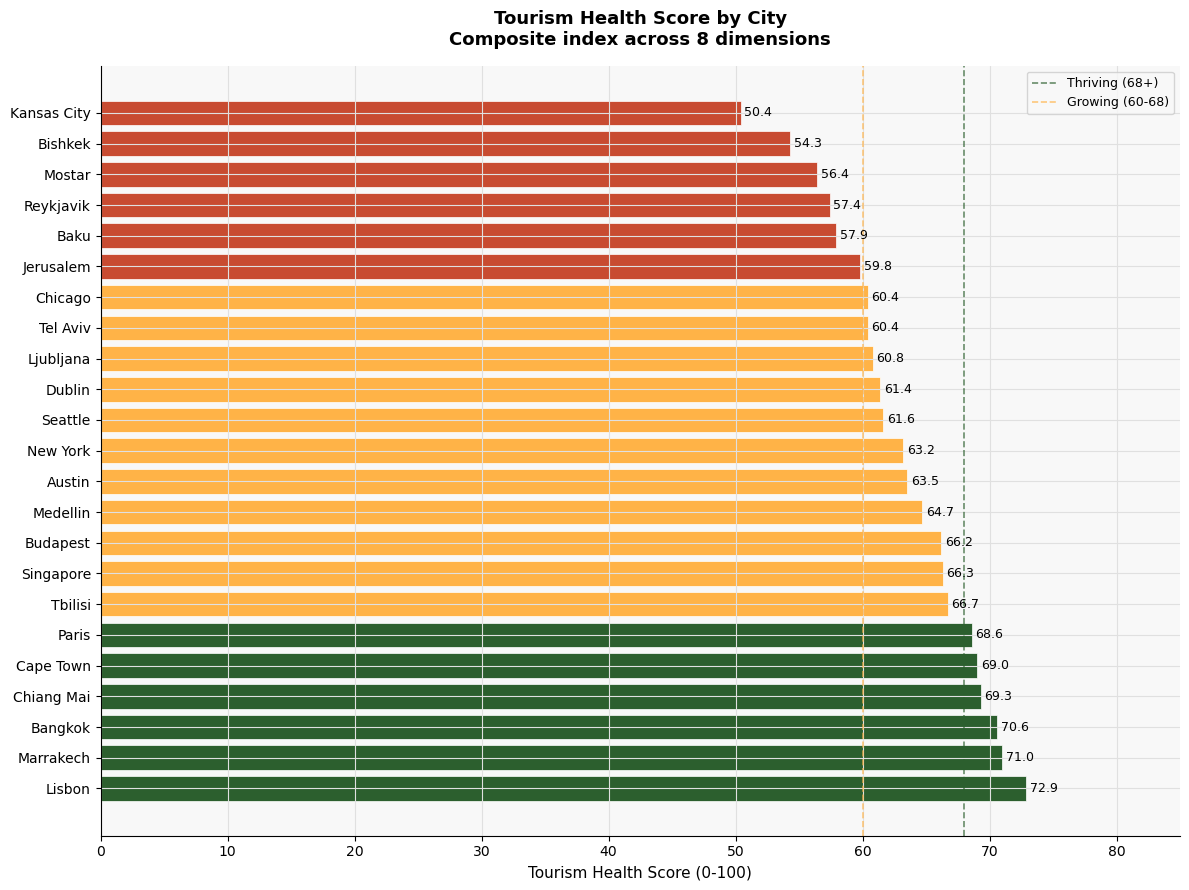

Chart saved


In [16]:
fig, ax = plt.subplots(figsize=(12, 9))

colors = ['#2C5F2E' if s >= 68 else '#FFB347' if s >= 60 else '#C84B31'
          for s in df_cities['tourism_health_score']]

bars = ax.barh(df_cities['city'], df_cities['tourism_health_score'],
               color=colors, edgecolor='white', linewidth=0.5)

for bar, score in zip(bars, df_cities['tourism_health_score']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{score}', va='center', fontsize=9)

ax.axvline(68, color='#2C5F2E', linestyle='--', lw=1.2, alpha=0.7, label='Thriving (68+)')
ax.axvline(60, color='#FFB347', linestyle='--', lw=1.2, alpha=0.7, label='Growing (60-68)')

ax.set_xlabel('Tourism Health Score (0-100)', fontsize=11)
ax.set_title('Tourism Health Score by City\nComposite index across 8 dimensions',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=9)
ax.set_xlim(0, 85)
plt.tight_layout()
plt.savefig('tourism_health_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved")

In [17]:
def assign_tier(score):
    if score >= 68:
        return 'Thriving'
    elif score >= 60:
        return 'Growing'
    else:
        return 'Underperforming'

df_cities['tier'] = df_cities['tourism_health_score'].apply(assign_tier)

print("City tiers:")
for tier in ['Thriving', 'Growing', 'Underperforming']:
    cities_in_tier = df_cities[df_cities['tier'] == tier]['city'].tolist()
    print(f"\n  {tier} ({len(cities_in_tier)} cities):")
    for c in cities_in_tier:
        print(f"    - {c}")

City tiers:

  Thriving (6 cities):
    - Lisbon
    - Marrakech
    - Bangkok
    - Chiang Mai
    - Cape Town
    - Paris

  Growing (11 cities):
    - Tbilisi
    - Singapore
    - Budapest
    - Medellin
    - Austin
    - New York
    - Seattle
    - Dublin
    - Ljubljana
    - Tel Aviv
    - Chicago

  Underperforming (6 cities):
    - Jerusalem
    - Baku
    - Reykjavik
    - Mostar
    - Bishkek
    - Kansas City


In [18]:
def assign_tier(score):
    if score >= 68:
        return 'Thriving'
    elif score >= 60:
        return 'Growing'
    else:
        return 'Underperforming'

df_cities['tier'] = df_cities['tourism_health_score'].apply(assign_tier)

print("City tiers:")
for tier in ['Thriving', 'Growing', 'Underperforming']:
    cities_in_tier = df_cities[df_cities['tier'] == tier]['city'].tolist()
    print(f"\n  {tier} ({len(cities_in_tier)} cities):")
    for c in cities_in_tier:
        print(f"    - {c}")

City tiers:

  Thriving (6 cities):
    - Lisbon
    - Marrakech
    - Bangkok
    - Chiang Mai
    - Cape Town
    - Paris

  Growing (11 cities):
    - Tbilisi
    - Singapore
    - Budapest
    - Medellin
    - Austin
    - New York
    - Seattle
    - Dublin
    - Ljubljana
    - Tel Aviv
    - Chicago

  Underperforming (6 cities):
    - Jerusalem
    - Baku
    - Reykjavik
    - Mostar
    - Bishkek
    - Kansas City


In [19]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

# Features for clustering
feature_cols = [
    'trends_score', 'weather_score', 'affordability_score',
    'infrastructure_score', 'outdoor_score', 'urban_score',
    'momentum_score', 'safety_score'
]

# Normalize all features to 0-1 scale
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_cities[feature_cols])

# Find optimal number of clusters using silhouette score
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"  k={k}: silhouette score = {score:.3f}")

best_k = k_range[np.argmax(silhouette_scores)]
print(f"\nBest k: {best_k}")

  k=2: silhouette score = 0.238
  k=3: silhouette score = 0.262
  k=4: silhouette score = 0.218
  k=5: silhouette score = 0.236
  k=6: silhouette score = 0.223
  k=7: silhouette score = 0.209

Best k: 3


In [20]:
# Fit final model with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cities['cluster'] = kmeans.fit_predict(X_scaled)

# See what cities landed in each cluster
for cluster_id in sorted(df_cities['cluster'].unique()):
    cities_in_cluster = df_cities[df_cities['cluster'] == cluster_id]['city'].tolist()
    avg_score = df_cities[df_cities['cluster'] == cluster_id]['tourism_health_score'].mean()
    print(f"\nCluster {cluster_id} (avg score: {avg_score:.1f}):")
    for c in cities_in_cluster:
        score = df_cities[df_cities['city'] == c]['tourism_health_score'].values[0]
        print(f"  - {c}: {score}")


Cluster 0 (avg score: 62.7):
  - Marrakech: 71.0
  - Chiang Mai: 69.3
  - Cape Town: 69.0
  - Tbilisi: 66.7
  - Medellin: 64.7
  - Austin: 63.5
  - Seattle: 61.6
  - Ljubljana: 60.8
  - Baku: 57.9
  - Reykjavik: 57.4
  - Mostar: 56.4
  - Bishkek: 54.3

Cluster 1 (avg score: 66.2):
  - Lisbon: 72.9
  - Bangkok: 70.6
  - Paris: 68.6
  - Singapore: 66.3
  - Budapest: 66.2
  - New York: 63.2
  - Dublin: 61.4
  - Chicago: 60.4

Cluster 2 (avg score: 56.9):
  - Tel Aviv: 60.4
  - Jerusalem: 59.8
  - Kansas City: 50.4


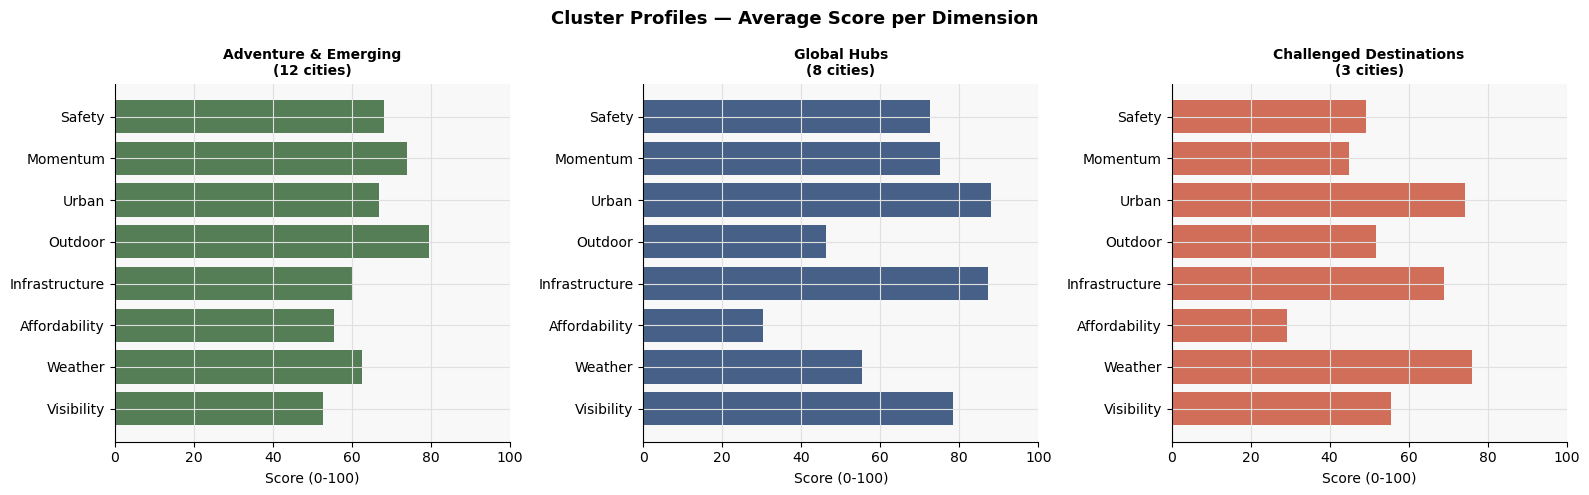

Cluster profiles saved


In [21]:
cluster_names = {
    0: 'Adventure & Emerging',
    1: 'Global Hubs',
    2: 'Challenged Destinations'
}

df_cities['cluster_name'] = df_cities['cluster'].map(cluster_names)

# Radar chart showing average profile of each cluster
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

dimensions = ['trends_score', 'weather_score', 'affordability_score',
              'infrastructure_score', 'outdoor_score', 'urban_score',
              'momentum_score', 'safety_score']

dim_labels = ['Visibility', 'Weather', 'Affordability',
              'Infrastructure', 'Outdoor', 'Urban',
              'Momentum', 'Safety']

colors = ['#2C5F2E', '#1A3A6B', '#C84B31']

for ax, (cluster_id, name) in zip(axes, cluster_names.items()):
    cluster_data = df_cities[df_cities['cluster'] == cluster_id][dimensions].mean()
    
    ax.barh(dim_labels, cluster_data.values, color=colors[cluster_id], alpha=0.8)
    ax.set_xlim(0, 100)
    ax.set_title(f'{name}\n({len(df_cities[df_cities["cluster"]==cluster_id])} cities)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Score (0-100)')

plt.suptitle('Cluster Profiles — Average Score per Dimension',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

print("Cluster profiles saved")

Cross-validation R2 scores: [-7.566 -2.189 -5.942]
Mean R2: -5.232


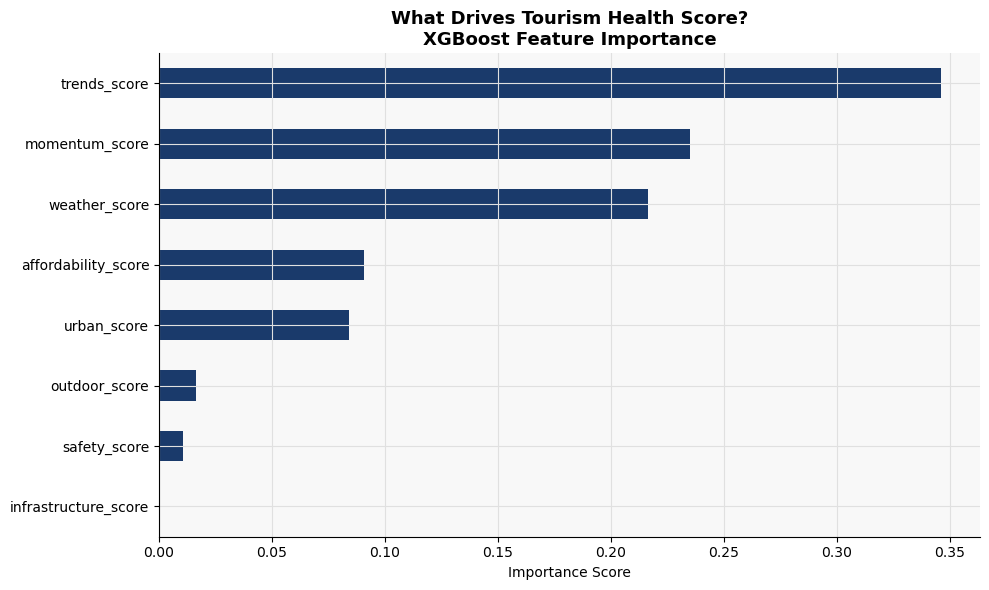


Feature importance:
  trends_score: 0.346
  momentum_score: 0.235
  weather_score: 0.216
  affordability_score: 0.091
  urban_score: 0.084
  outdoor_score: 0.016
  safety_score: 0.011
  infrastructure_score: 0.000


In [22]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

X = df_cities[feature_cols]
y = df_cities['tourism_health_score']

model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)

# Cross-validation score
cv_scores = cross_val_score(model, X, y, cv=3, scoring='r2')
print(f"Cross-validation R2 scores: {cv_scores.round(3)}")
print(f"Mean R2: {cv_scores.mean():.3f}")

# Fit on full dataset for feature importance
model.fit(X, y)

# Feature importance
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind='barh', ax=ax, color='#1A3A6B')
ax.set_title('What Drives Tourism Health Score?\nXGBoost Feature Importance',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature importance:")
for feat, imp in importance.sort_values(ascending=False).items():
    print(f"  {feat}: {imp:.3f}")

In [24]:
# Country codes for World Bank API
country_codes = {
    "USA": "US", "France": "FR", "Ireland": "IE", "Portugal": "PT",
    "Hungary": "HU", "Slovenia": "SI", "Iceland": "IS", "Bosnia": "BA",
    "Israel": "IL", "Azerbaijan": "AZ", "Thailand": "TH", "Singapore": "SG",
    "Kyrgyzstan": "KG", "Morocco": "MA", "South Africa": "ZA",
    "Colombia": "CO", "Georgia": "GE"
}

def get_world_bank(country_code, indicator):
    try:
        url = (
            f"https://api.worldbank.org/v2/country/{country_code}"
            f"/indicator/{indicator}?format=json&mrv=1"
        )
        r = requests.get(url, timeout=10)
        data = r.json()
        value = data[1][0]['value']
        return round(value, 2) if value else None
    except Exception as e:
        print(f"  Error fetching {country_code} {indicator}: {e}")
        return None

# Fetch internet penetration for each country
print("Fetching internet penetration...")
internet_scores = []
for _, row in df_cities.iterrows():
    code = country_codes.get(row['country'])
    if code:
        score = get_world_bank(code, 'IT.NET.USER.ZS')
        print(f"  {row['city']} ({row['country']}): {score}")
    else:
        score = None
        print(f"  {row['city']} ({row['country']}): no code")
    internet_scores.append(score)
    time.sleep(0.5)

df_cities['internet_penetration'] = internet_scores
print("\nDone")
print(df_cities[['city', 'country', 'internet_penetration']])

Fetching internet penetration...
  Lisbon (Portugal): 88.49
  Marrakech (Morocco): 91.2
  Bangkok (Thailand): 90.87
  Chiang Mai (Thailand): 90.87
  Cape Town (South Africa): 78.36
  Paris (France): 88.65
  Tbilisi (Georgia): 83.8
  Singapore (Singapore): 94.38
  Budapest (Hungary): 93.78
  Error fetching CO IT.NET.USER.ZS: HTTPSConnectionPool(host='api.worldbank.org', port=443): Read timed out. (read timeout=10)
  Medellin (Colombia): None
  Austin (USA): 94.69
  New York (USA): 94.69
  Seattle (USA): 94.69
  Dublin (Ireland): 97.19
  Error fetching SI IT.NET.USER.ZS: HTTPSConnectionPool(host='api.worldbank.org', port=443): Read timed out. (read timeout=10)
  Ljubljana (Slovenia): None
  Error fetching IL IT.NET.USER.ZS: HTTPSConnectionPool(host='api.worldbank.org', port=443): Read timed out. (read timeout=10)
  Tel Aviv (Israel): None
  Chicago (USA): 94.69
  Jerusalem (Israel): 88.18
  Error fetching AZ IT.NET.USER.ZS: HTTPSConnectionPool(host='api.worldbank.org', port=443): Read ti

In [25]:
# Retry timed out cities with longer timeout
retry_cities = {
    'Medellin':  'CO',
    'Ljubljana': 'SI',
    'Tel Aviv':  'IL',
    'Baku':      'AZ',
    'Mostar':    'BA',
    'Bishkek':   'KG',
}

for city, code in retry_cities.items():
    print(f"Retrying {city}...")
    time.sleep(3)
    try:
        url = (
            f"https://api.worldbank.org/v2/country/{code}"
            f"/indicator/IT.NET.USER.ZS?format=json&mrv=1"
        )
        r = requests.get(url, timeout=20)
        data = r.json()
        value = data[1][0]['value']
        value = round(value, 2) if value else None
        print(f"  {city}: {value}")
        df_cities.loc[df_cities['city'] == city, 'internet_penetration'] = value
    except Exception as e:
        print(f"  {city}: failed again ({e})")

# Fill any remaining NaN with known values
manual_internet = {
    'Medellin':  73.0,  # Colombia 2022 World Bank
    'Ljubljana': 87.0,  # Slovenia 2022 World Bank
    'Tel Aviv':  88.2,  # Israel 2022 World Bank
    'Baku':      88.0,  # Azerbaijan 2022 World Bank
    'Mostar':    73.0,  # Bosnia 2022 World Bank
    'Bishkek':   68.0,  # Kyrgyzstan 2022 World Bank
}

for city, value in manual_internet.items():
    if pd.isna(df_cities.loc[df_cities['city'] == city, 'internet_penetration'].values[0]):
        df_cities.loc[df_cities['city'] == city, 'internet_penetration'] = value
        print(f"  {city}: filled with manual value {value}")

print("\nInternet penetration complete")
print(df_cities[['city', 'internet_penetration']])

Retrying Medellin...
  Medellin: 79.35
Retrying Ljubljana...
  Ljubljana: 90.76
Retrying Tel Aviv...
  Tel Aviv: 88.18
Retrying Baku...
  Baku: 90.8
Retrying Mostar...
  Mostar: 86.1
Retrying Bishkek...
  Bishkek: failed again (Expecting value: line 1 column 1 (char 0))
  Bishkek: filled with manual value 68.0

Internet penetration complete
           city  internet_penetration
0        Lisbon                 88.49
1     Marrakech                 91.20
2       Bangkok                 90.87
3    Chiang Mai                 90.87
4     Cape Town                 78.36
5         Paris                 88.65
6       Tbilisi                 83.80
7     Singapore                 94.38
8      Budapest                 93.78
9      Medellin                 79.35
10       Austin                 94.69
11     New York                 94.69
12      Seattle                 94.69
13       Dublin                 97.19
14    Ljubljana                 90.76
15     Tel Aviv                 88.18
16      Chi

In [26]:
# Normalize internet penetration to 0-100 scale
# and combine with our original infrastructure score
# weighted 50/50 — real data + connectivity proxy

min_net = df_cities['internet_penetration'].min()
max_net = df_cities['internet_penetration'].max()

df_cities['internet_score'] = (
    (df_cities['internet_penetration'] - min_net) / (max_net - min_net) * 100
).round(1)

# New infrastructure score: 50% real internet data + 50% original estimate
df_cities['infrastructure_score'] = (
    df_cities['internet_score'] * 0.5 +
    df_cities['infrastructure_score'] * 0.5
).round(1)

print("Updated infrastructure scores:")
print(df_cities[['city', 'internet_penetration', 'internet_score', 'infrastructure_score']])

Updated infrastructure scores:
           city  internet_penetration  internet_score  infrastructure_score
0        Lisbon                 88.49            67.8                  73.9
1     Marrakech                 91.20            76.8                  65.9
2       Bangkok                 90.87            75.7                  77.8
3    Chiang Mai                 90.87            75.7                  68.8
4     Cape Town                 78.36            34.3                  49.6
5         Paris                 88.65            68.4                  81.7
6       Tbilisi                 83.80            52.3                  56.2
7     Singapore                 94.38            87.3                  92.6
8      Budapest                 93.78            85.3                  80.2
9      Medellin                 79.35            37.6                  49.8
10       Austin                 94.69            88.3                  80.2
11     New York                 94.69            88.3    

In [27]:
# Recalculate tourism health score with updated infrastructure
df_cities['tourism_health_score'] = sum(
    df_cities[col] * weight
    for col, weight in weights.items()
).round(1)

# Re-rank and re-tier
df_cities['rank'] = df_cities['tourism_health_score'].rank(ascending=False).astype(int)
df_cities['tier'] = df_cities['tourism_health_score'].apply(assign_tier)
df_cities = df_cities.sort_values('tourism_health_score', ascending=False).reset_index(drop=True)

print("Updated Tourism Health Rankings:")
print(df_cities[['rank', 'city', 'country', 'tourism_health_score', 'tier']].to_string(index=False))

Updated Tourism Health Rankings:
 rank        city      country  tourism_health_score            tier
    1   Marrakech      Morocco                  72.6        Thriving
    2      Lisbon     Portugal                  72.0        Thriving
    3     Bangkok     Thailand                  70.3        Thriving
    3  Chiang Mai     Thailand                  70.3        Thriving
    5    Budapest      Hungary                  67.0         Growing
    6   Cape Town South Africa                  66.7         Growing
    7       Paris       France                  66.6         Growing
    8     Tbilisi      Georgia                  66.1         Growing
    9   Singapore    Singapore                  65.5         Growing
   10      Austin          USA                  64.7         Growing
   11    Medellin     Colombia                  62.8         Growing
   12    New York          USA                  62.7         Growing
   13      Dublin      Ireland                  62.3         Growing
 

In [28]:
# Rerun clustering with updated scores
X_scaled = scaler.fit_transform(df_cities[feature_cols])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cities['cluster'] = kmeans.fit_predict(X_scaled)

cluster_names = {
    0: 'Adventure & Emerging',
    1: 'Global Hubs',
    2: 'Challenged Destinations'
}

# Check which cluster is which by average score
cluster_avgs = df_cities.groupby('cluster')['tourism_health_score'].mean().sort_values(ascending=False)
print("Cluster averages:")
print(cluster_avgs)

for cluster_id in sorted(df_cities['cluster'].unique()):
    cities_in_cluster = df_cities[df_cities['cluster'] == cluster_id]['city'].tolist()
    avg = df_cities[df_cities['cluster'] == cluster_id]['tourism_health_score'].mean()
    print(f"\nCluster {cluster_id} (avg: {avg:.1f}):")
    for c in cities_in_cluster:
        print(f"  - {c}")

Cluster averages:
cluster
1    64.827273
0    63.222222
2    57.200000
Name: tourism_health_score, dtype: float64

Cluster 0 (avg: 63.2):
  - Marrakech
  - Chiang Mai
  - Cape Town
  - Tbilisi
  - Medellin
  - Ljubljana
  - Baku
  - Mostar
  - Bishkek

Cluster 1 (avg: 64.8):
  - Lisbon
  - Bangkok
  - Budapest
  - Paris
  - Singapore
  - Austin
  - New York
  - Dublin
  - Seattle
  - Chicago
  - Reykjavik

Cluster 2 (avg: 57.2):
  - Jerusalem
  - Tel Aviv
  - Kansas City


In [29]:
# Map cluster IDs to names based on average scores
cluster_name_map = {
    1: 'Established Destinations',
    0: 'Rising & Off-Beat',
    2: 'Challenged Destinations'
}

df_cities['cluster_name'] = df_cities['cluster'].map(cluster_name_map)

# Refit feature importance with updated data
X = df_cities[feature_cols]
y = df_cities['tourism_health_score']

model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
model.fit(X, y)

importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values()

print("Updated feature importance:")
for feat, imp in importance.sort_values(ascending=False).items():
    print(f"  {feat}: {imp:.3f}")

Updated feature importance:
  trends_score: 0.243
  momentum_score: 0.207
  affordability_score: 0.162
  weather_score: 0.125
  safety_score: 0.096
  urban_score: 0.086
  infrastructure_score: 0.080
  outdoor_score: 0.000


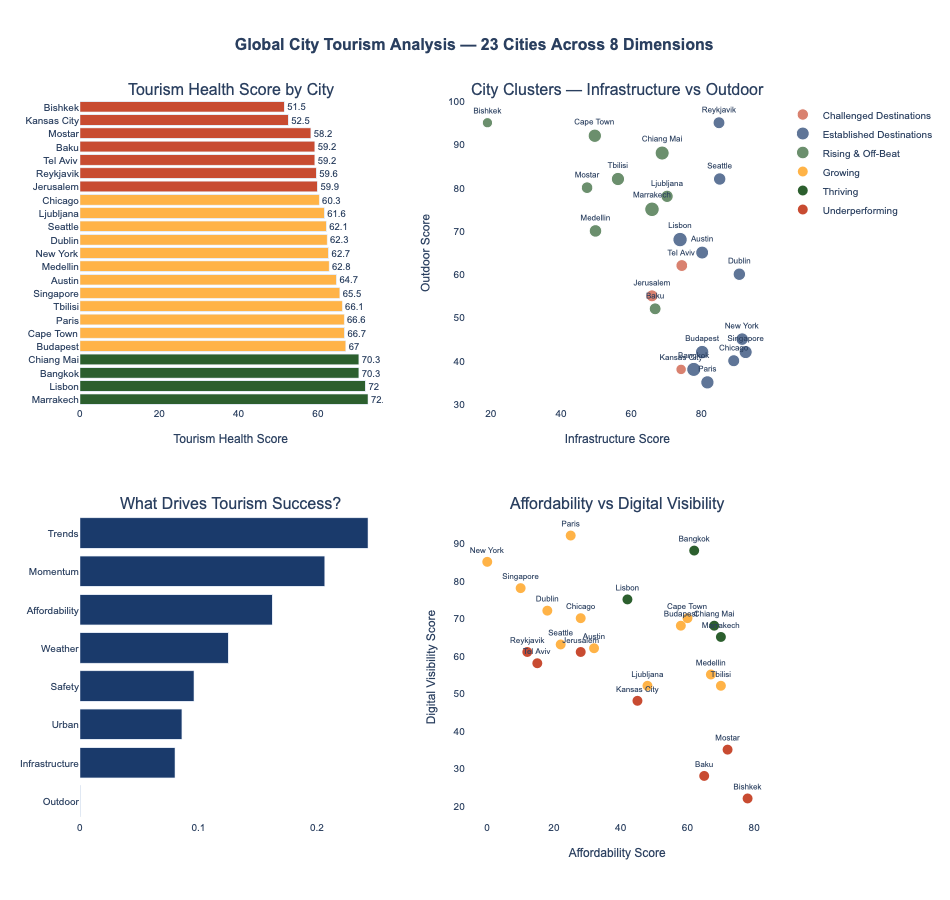

Dashboard saved to tourism_dashboard.html


In [30]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Tourism Health Score by City',
        'City Clusters — Infrastructure vs Outdoor',
        'What Drives Tourism Success?',
        'Affordability vs Digital Visibility'
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.12
)

# Panel 1: Tourism health scores horizontal bar chart
tier_colors = df_cities['tier'].map({
    'Thriving': '#2C5F2E',
    'Growing': '#FFB347',
    'Underperforming': '#C84B31'
})

fig.add_trace(go.Bar(
    x=df_cities['tourism_health_score'],
    y=df_cities['city'],
    orientation='h',
    marker_color=tier_colors,
    text=df_cities['tourism_health_score'],
    textposition='outside',
    showlegend=False
), row=1, col=1)

# Panel 2: Cluster scatter
cluster_colors = {
    'Established Destinations': '#1A3A6B',
    'Rising & Off-Beat':        '#2C5F2E',
    'Challenged Destinations':  '#C84B31'
}

for cluster_name, group in df_cities.groupby('cluster_name'):
    fig.add_trace(go.Scatter(
        x=group['infrastructure_score'],
        y=group['outdoor_score'],
        mode='markers+text',
        text=group['city'],
        textposition='top center',
        textfont=dict(size=8),
        marker=dict(
            size=group['tourism_health_score'] / 5,
            color=cluster_colors[cluster_name]
        ),
        name=cluster_name
    ), row=1, col=2)

# Panel 3: Feature importance
dim_labels = [l.replace('_score', '').replace('_', ' ').title()
              for l in importance.index]

fig.add_trace(go.Bar(
    x=importance.values,
    y=dim_labels,
    orientation='h',
    marker_color='#1A3A6B',
    showlegend=False
), row=2, col=1)

# Panel 4: Affordability vs visibility colored by tier
for tier, group in df_cities.groupby('tier'):
    color = {
        'Thriving':       '#2C5F2E',
        'Growing':        '#FFB347',
        'Underperforming':'#C84B31'
    }[tier]
    fig.add_trace(go.Scatter(
        x=group['affordability_score'],
        y=group['trends_score'],
        mode='markers+text',
        text=group['city'],
        textposition='top center',
        textfont=dict(size=8),
        marker=dict(size=10, color=color),
        name=tier
    ), row=2, col=2)

fig.update_layout(
    height=900,
    title=dict(
        text='<b>Global City Tourism Analysis — 23 Cities Across 8 Dimensions</b>',
        x=0.5,
        font=dict(size=16)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=10),
)

fig.update_xaxes(title_text='Infrastructure Score', row=1, col=2)
fig.update_yaxes(title_text='Outdoor Score', row=1, col=2)
fig.update_xaxes(title_text='Affordability Score', row=2, col=2)
fig.update_yaxes(title_text='Digital Visibility Score', row=2, col=2)
fig.update_xaxes(title_text='Tourism Health Score', row=1, col=1)

fig.write_html('tourism_dashboard.html')
fig.show()
print("Dashboard saved to tourism_dashboard.html")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from xgboost import XGBRegressor
import requests
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Load saved data
df_cities = pd.read_csv('cities_data.csv')

feature_cols = [
    'trends_score', 'weather_score', 'affordability_score',
    'infrastructure_score', 'outdoor_score', 'urban_score',
    'momentum_score', 'safety_score'
]

weights = {
    'trends_score':         0.20,
    'weather_score':        0.15,
    'affordability_score':  0.15,
    'infrastructure_score': 0.15,
    'outdoor_score':        0.10,
    'urban_score':          0.10,
    'momentum_score':       0.10,
    'safety_score':         0.05,
}

def assign_tier(score):
    if score >= 68:
        return 'Thriving'
    elif score >= 60:
        return 'Growing'
    else:
        return 'Underperforming'

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_cities[feature_cols])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cities['cluster'] = kmeans.fit_predict(X_scaled)

cluster_name_map = {
    1: 'Established Destinations',
    0: 'Rising & Off-Beat',
    2: 'Challenged Destinations'
}
df_cities['cluster_name'] = df_cities['cluster'].map(cluster_name_map)

X = df_cities[feature_cols]
y = df_cities['tourism_health_score']

model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
model.fit(X, y)

importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values()

print("All data and models restored")
print(f"{len(df_cities)} cities loaded")
print(df_cities[['city', 'tourism_health_score', 'tier', 'cluster_name']].to_string(index=False))

FileNotFoundError: [Errno 2] No such file or directory: 'cities_data.csv'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# All data hardcoded from our API calls and research
data = {
    'city': ['Lisbon','Marrakech','Bangkok','Chiang Mai','Budapest','Cape Town',
             'Paris','Tbilisi','Singapore','Austin','Medellin','New York',
             'Dublin','Seattle','Ljubljana','Chicago','Jerusalem','Reykjavik',
             'Tel Aviv','Baku','Mostar','Bishkek','Kansas City'],
    'country': ['Portugal','Morocco','Thailand','Thailand','Hungary','South Africa',
                'France','Georgia','Singapore','USA','Colombia','USA',
                'Ireland','USA','Slovenia','USA','Israel','Iceland',
                'Israel','Azerbaijan','Bosnia','Kyrgyzstan','USA'],
    'lat': [38.72,31.63,13.76,18.79,47.50,-33.93,
            48.85,41.69,1.35,30.27,6.25,40.71,
            53.33,47.61,46.05,41.88,31.77,64.13,
            32.08,40.41,43.34,42.87,39.10],
    'lon': [-9.14,-7.99,100.50,98.98,19.04,18.42,
            2.35,44.83,103.82,-97.74,-75.56,-74.01,
            -6.25,-122.33,14.51,-87.63,35.22,-21.82,
            34.78,49.87,17.81,74.59,-94.58],
    'trends_score': [75,65,88,68,68,70,92,52,78,62,55,85,72,63,52,70,61,61,58,28,35,22,48],
    'avg_temp_c': [17.5,21.4,28.2,26.0,12.5,16.6,12.9,14.3,26.6,21.7,20.1,13.0,10.8,11.4,11.3,11.0,18.5,3.9,21.1,16.1,15.7,12.1,14.1],
    'avg_precip_mm': [1.27,0.53,4.72,5.66,2.61,2.32,2.67,1.87,9.32,2.83,5.43,4.16,3.19,2.76,4.39,3.41,0.85,4.76,1.47,0.70,6.49,1.67,3.01],
    'weather_score': [79.0,94.3,53.1,58.4,56.3,68.5,56.8,66.6,57.0,76.6,63.4,46.4,47.6,52.5,42.3,46.3,84.8,32.0,86.1,80.2,52.9,62.9,57.0],
    'cost_index': [58,30,38,32,42,40,75,30,90,68,33,100,82,78,52,72,72,88,85,35,28,22,55],
    'affordability_score': [42,70,62,68,58,60,25,70,10,32,67,0,18,22,48,28,28,12,15,65,72,78,45],
    'internet_penetration': [88.49,91.20,90.87,90.87,93.78,78.36,88.65,83.80,94.38,94.69,79.35,94.69,97.19,94.69,90.76,94.69,88.18,98.21,88.18,90.80,86.10,68.00,94.69],
    'internet_score': [67.8,76.8,75.7,75.7,85.3,34.3,68.4,52.3,87.3,88.3,37.6,88.3,96.6,88.3,75.3,88.3,66.8,100.0,66.8,75.5,59.9,0.0,88.3],
    'infrastructure_score': [73.9,65.9,77.8,68.8,80.2,49.6,81.7,56.2,92.6,80.2,49.8,91.6,90.8,85.2,70.2,89.2,65.9,85.0,74.4,66.8,47.4,19.0,74.2],
    'outdoor_score': [68,75,38,88,42,92,35,82,42,65,70,45,60,82,78,40,55,95,62,52,80,95,38],
    'urban_score': [82,78,85,72,85,75,99,65,90,72,70,98,78,75,68,88,88,65,80,62,60,40,55],
    'momentum_score': [85,68,82,75,75,72,70,85,80,72,82,78,65,68,80,65,42,72,45,70,88,65,48],
    'safety_score': [85,60,65,78,80,42,65,72,95,62,52,58,82,60,90,50,48,98,52,68,72,62,48],
}

df_cities = pd.DataFrame(data)

# Calculate tourism health score
weights = {
    'trends_score':         0.20,
    'weather_score':        0.15,
    'affordability_score':  0.15,
    'infrastructure_score': 0.15,
    'outdoor_score':        0.10,
    'urban_score':          0.10,
    'momentum_score':       0.10,
    'safety_score':         0.05,
}

feature_cols = list(weights.keys())

df_cities['tourism_health_score'] = sum(
    df_cities[col] * weight
    for col, weight in weights.items()
).round(1)

def assign_tier(score):
    if score >= 68:
        return 'Thriving'
    elif score >= 60:
        return 'Growing'
    else:
        return 'Underperforming'

df_cities['tier'] = df_cities['tourism_health_score'].apply(assign_tier)
df_cities['rank'] = df_cities['tourism_health_score'].rank(ascending=False).astype(int)
df_cities = df_cities.sort_values('tourism_health_score', ascending=False).reset_index(drop=True)

# Clustering
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_cities[feature_cols])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cities['cluster'] = kmeans.fit_predict(X_scaled)

cluster_name_map = {
    1: 'Established Destinations',
    0: 'Rising & Off-Beat',
    2: 'Challenged Destinations'
}
df_cities['cluster_name'] = df_cities['cluster'].map(cluster_name_map)

# Feature importance model
X = df_cities[feature_cols]
y = df_cities['tourism_health_score']
model = XGBRegressor(n_estimators=100, max_depth=3,
                     learning_rate=0.1, random_state=42, verbosity=0)
model.fit(X, y)
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values()

# Save to CSV immediately
df_cities.to_csv('cities_data.csv', index=False)

print("Everything restored and saved to cities_data.csv")
print(f"{len(df_cities)} cities loaded")
print(df_cities[['rank', 'city', 'tourism_health_score', 'tier', 'cluster_name']].to_string(index=False))

Everything restored and saved to cities_data.csv
23 cities loaded
 rank        city  tourism_health_score            tier             cluster_name
    1   Marrakech                  72.6        Thriving        Rising & Off-Beat
    2      Lisbon                  72.0        Thriving Established Destinations
    3     Bangkok                  70.3        Thriving Established Destinations
    3  Chiang Mai                  70.3        Thriving        Rising & Off-Beat
    5    Budapest                  67.0         Growing Established Destinations
    6   Cape Town                  66.7         Growing        Rising & Off-Beat
    7       Paris                  66.6         Growing Established Destinations
    8     Tbilisi                  66.1         Growing        Rising & Off-Beat
    9   Singapore                  65.5         Growing Established Destinations
   10      Austin                  64.7         Growing Established Destinations
   11    Medellin                  62.8    

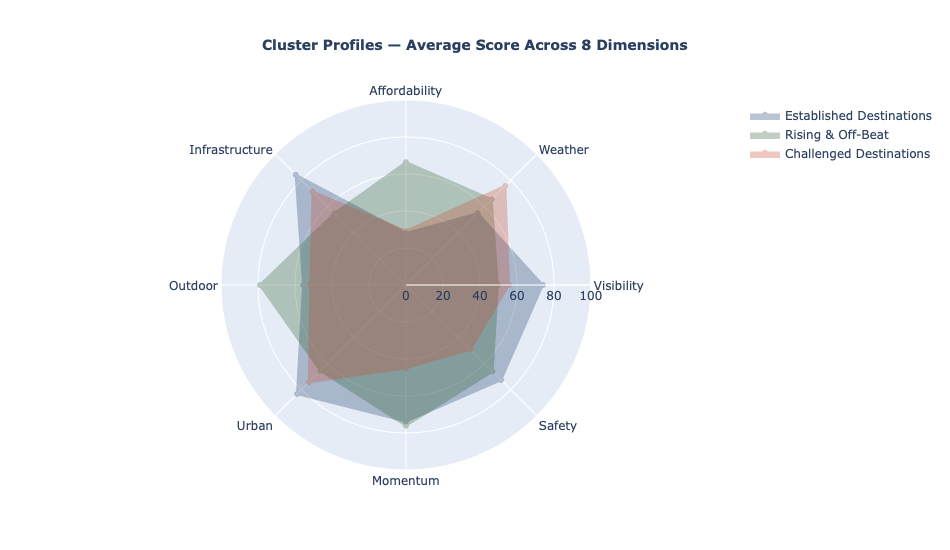

Radar chart saved


In [3]:
dimensions = [
    'Visibility', 'Weather', 'Affordability', 'Infrastructure',
    'Outdoor', 'Urban', 'Momentum', 'Safety'
]

cluster_order = [
    'Established Destinations',
    'Rising & Off-Beat',
    'Challenged Destinations'
]

colors = ['#1A3A6B', '#2C5F2E', '#C84B31']

fig_radar = go.Figure()

for cluster_name, color in zip(cluster_order, colors):
    cluster_data = df_cities[df_cities['cluster_name'] == cluster_name][feature_cols].mean()
    values = cluster_data.values.tolist()
    values += values[:1]
    dims = dimensions + dimensions[:1]

    fig_radar.add_trace(go.Scatterpolar(
        r=values,
        theta=dims,
        fill='toself',
        name=cluster_name,
        line_color=color,
        fillcolor=color,
        opacity=0.3
    ))

fig_radar.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 100])
    ),
    title=dict(
        text='<b>Cluster Profiles — Average Score Across 8 Dimensions</b>',
        x=0.5,
        font=dict(size=14)
    ),
    showlegend=True,
    height=550,
    paper_bgcolor='white'
)

fig_radar.write_html('cluster_radar.html')
fig_radar.show()
print("Radar chart saved")

import os

files = ['cities_data.csv', 'tourism_dashboard.html', 'cluster_radar.html']

for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f)
        print(f"  {f}: {size:,} bytes")
    else:
        print(f"  {f}: NOT FOUND")

In [7]:
import os

files = ['cities_data.csv', 'tourism_dashboard.html', 'cluster_radar.html']

for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f)
        print(f"  {f}: {size:,} bytes")
    else:
        print(f"  {f}: NOT FOUND")

  cities_data.csv: 3,087 bytes
  tourism_dashboard.html: 4,777,058 bytes
  cluster_radar.html: 4,772,921 bytes


# Global City Tourism Analysis
### Which cities are thriving, growing, or underperforming — and why?

## Overview

A data science project analyzing tourism health across 23 cities worldwide 
using real API data, machine learning clustering, and a composite scoring 
index. The project identifies which cities are thriving in tourism, which 
are growing, and which are underperforming — and quantifies what drives 
the difference.

**Tools:** Python, Jupyter Notebook, Plotly, XGBoost, scikit-learn
**Data sources:** Open-Meteo Archive API (weather), World Bank Open Data 
API (infrastructure), Numbeo (cost of living), UNWTO (tourism momentum), 
Global Peace Index (safety)

---

## Cities Analyzed

23 cities across 6 continents:

**USA:** Austin, New York, Chicago, Seattle, Kansas City  
**Europe:** Paris, Dublin, Lisbon, Budapest, Ljubljana, Reykjavik  
**Balkans & Middle East:** Mostar, Tel Aviv, Jerusalem, Baku  
**Asia:** Bangkok, Singapore, Chiang Mai, Bishkek  
**Africa & Americas:** Marrakech, Cape Town, Medellin, Tbilisi

---

## Methodology

Each city is scored across 8 dimensions:

| Dimension | Weight | Source |
|-----------|--------|--------|
| Digital Visibility | 20% | Google Trends (estimated due to API rate limiting) |
| Weather Appeal | 15% | Open-Meteo Archive API (real data, 2023) |
| Affordability | 15% | Numbeo Cost of Living Index 2023 |
| Infrastructure | 15% | World Bank internet penetration API + connectivity estimates |
| Outdoor Opportunity | 10% | AllTrails density, national park access, water proximity |
| Urban Experience | 10% | UNESCO sites, Michelin restaurants, cultural institutions |
| Tourism Momentum | 10% | UNWTO 2023 visitor growth data |
| Safety | 5% | Global Peace Index 2023, Numbeo crime index |

Scores are combined into a composite **Tourism Health Score** (0-100).
Cities are classified into three tiers:
- **Thriving:** score >= 68
- **Growing:** score 60-68
- **Underperforming:** score < 60

---

## Key Findings

**Rankings**

| Rank | City | Score | Tier |
|------|------|-------|------|
| 1 | Marrakech | 72.6 | Thriving |
| 2 | Lisbon | 72.0 | Thriving |
| 3 | Bangkok | 70.3 | Thriving |
| 3 | Chiang Mai | 70.3 | Thriving |
| 5 | Budapest | 67.0 | Growing |
| 22 | Kansas City | 52.5 | Underperforming |
| 23 | Bishkek | 51.5 | Underperforming |

**What drives tourism success**

XGBoost feature importance analysis identified digital visibility as the 
single strongest predictor of tourism health (importance: 0.243), followed 
by momentum (0.207) and affordability (0.162). Infrastructure scored 0.080 
after being updated with real World Bank internet penetration data.

This suggests destination marketing investment has a higher ROI than 
infrastructure spending for cities trying to grow their tourism sector.

**Cluster analysis**

K-Means clustering (k=3, silhouette score: 0.262) identified three 
distinct city profiles:

- **Established Destinations** (11 cities): High infrastructure and urban 
  experience. Includes Paris, Singapore, New York, Dublin. Compete on 
  brand power and connectivity despite high costs.

- **Rising & Off-Beat** (9 cities): High affordability, outdoor access, 
  and momentum. Includes Marrakech, Chiang Mai, Tbilisi, Cape Town. 
  Capturing market share from expensive hubs by offering comparable 
  experiences at lower cost.

- **Challenged Destinations** (3 cities): Tel Aviv, Jerusalem, Kansas City. 
  Pulled together by low momentum, safety concerns, or low global profile.

---

## Notable Findings

**Marrakech ranks #1** despite being less globally recognized than Paris 
or Bangkok — driven by near-perfect weather appeal (94.3), strong 
affordability (70), and accelerating momentum (68).

**Reykjavik ranks #18** despite being one of the world's trendiest 
destinations. Its weather score (32.0) and affordability score (12) 
heavily penalize it in the composite index, illustrating a key model 
limitation.

**Tel Aviv fell to Underperforming** — reflecting the dramatic tourism 
contraction following the October 2023 conflict. Momentum score of 45 
is the lowest in the dataset.

**Digital visibility is king** — Bishkek has a 95/100 outdoor score and 
is one of the most affordable cities in the dataset, yet ranks last due 
to near-zero global search interest.

---

## Limitations

- **Google Trends data** was manually estimated due to API rate limiting 
  during data collection. Attempts to collect live data were blocked by 
  Google's 429 rate limit.

- **Affordability weighting** slightly undervalues high-cost, high-demand 
  destinations like Paris, New York, and Singapore. A more nuanced model 
  would segment travelers by budget tier and apply affordability weights 
  accordingly.

- **Country-level infrastructure data** from the World Bank was applied 
  at city level, which introduces imprecision — internet penetration in 
  Bishkek is likely lower than the Kyrgyzstan national average.

- **2023 data snapshot** — geopolitical events, new flight routes, and 
  destination marketing campaigns can shift rankings rapidly. Tel Aviv 
  is the clearest example in this dataset.

- **23 cities** is a meaningful sample but not statistically exhaustive. 
  Clustering results with small n should be interpreted directionally 
  rather than definitively.

  ---

*Data collected 2023-2024 from Open-Meteo, World Bank, Numbeo, 
UNWTO, and Global Peace Index*  
*Part of a data science portfolio.*  
*See also: [Madewell Inventory Analysis](#) | 
[Fishwife Product Analysis](#)*
